<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 7: Classification

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li> 
    <li><a href='#background_binary_classification' style="color:#1B5E20;"><strong>Background:</strong> Binary Classification</a></li>
    <li><a href='#binaryclassificationexample' style="color:black;">Example: Classifying Sine and Square Waves</a></li>    
    <li><a href='#binaryclassificationpytorch' style="color:black;">Binary Classification Using PyTorch</a></li>
    <li><a href='#nnsequential' style="color:black;">Defining Compact Models with Sequential Layers</a></li> 
    <li><a href='#background_multiclass_classification' style="color:#1B5E20;"><strong>Background:</strong> Multiclass Classification</a></li>
    <li><a href='#multiclassfrequencyexample' style="color:black;">Example: Classifying Waveforms by Frequency</a></li>     
    <li><a href='#background_pitch_estimation' style="color:#1B5E20;"><strong>Background:</strong> Pitch and Fundamental Frequency (F0)</a></li>
    <li><a href='#multiclassclassificationpytorch' style="color:black;">Multiclass Classification Using PyTorch</a></li>     
    <li><a href='#evaluation' style="color:black;">Model Evaluation and Understanding</a></li>  
    <li><a href='#exercise_binary_cross_entropy' style="color:#006064;"><strong>Exercise 1:</strong> Understanding Binary Cross-Entropy Loss</a></li>
    <li><a href='#background_logistic_loss' style="color:#1B5E20;"><strong>Background:</strong> Logistic Loss</a></li>    
    <li><a href='#exercise_softmax_multiclass' style="color:#006064;"><strong>Exercise 2:</strong> Exploring Softmax and Cross-Entropy in Multiclass Classification</a></li>    
    <li><a href='#exercise_classification_FFT' style="color:#006064;"><strong>Exercise 3:</strong> Frequency Classification from FFT Features</a></li>
    <li><a href='#exercise_pointcloud_classification' style="color:#006064;"><strong>Exercise 4:</strong>  Classification of Intertwined 2D Point Clouds</a></li>    
</ul>   

<a id='learn'></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This unit introduces the core principles of <strong>classification</strong> in supervised learning with PyTorch, building on the signal-based setups explored in earlier units. Unlike regression tasks, which predict continuous values, classification assigns discrete class labels to input signals. We begin with simple <strong>binary classification</strong> problems (e.g., distinguishing sine from square waves) and progress to more complex <strong>multi-class classification</strong> tasks that require recognizing frequency patterns. Along the way, we introduce essential PyTorch tools such as softmax activations, cross-entropy loss, and the interpretation of probabilistic outputs. The learning objectives of this unit are as follows: 
</p>

<ul style="color:#E65100;">
<li>Differentiate between binary and multi-class classification in supervised learning.</li>
<li>Apply sigmoid and softmax activations to produce probabilistic prediction scores.</li>    
<li>Explain the role of logits and their interaction with activation functions and loss definitions.</li>
<li>Build multi-layer neural networks for classification using PyTorch modules.</li>
<li>Use classification-specific loss functions such as <code>nn.BCEWithLogitsLoss</code> for binary tasks and <code>nn.CrossEntropyLoss</code> for multi-class tasks.</li>
<li>Evaluate classifiers using accuracy, confusion matrices, and out-of-distribution (OOD) tests.</li>
</ul>

<p style="color:#E65100;">
The unit includes four hands-on exercises:
</p>
<ul style="color:#E65100;">
<li><a href="#exercise_binary_cross_entropy">Exercise 1</a>: Implement binary classification and binary cross-entropy loss.</li>
<li><a href="#exercise_softmax_multiclass">Exercise 2</a>: Explore softmax-based multi-class classification.</li>
<li><a href="#exercise_classification_FFT">Exercise 3</a>: Classify frequency features extracted via the Fast Fourier Transfrom (FFT).</li>
<li><a href="#exercise_pointcloud_classification">Exercise 4</a>: Distinguish overlapping geometric patterns in 2D point clouds.</li>
</ul>

<p style="color:#E65100;">
Together, these exercises provide practical experience in designing, training, and evaluating classifiers across different signal domains. For further reference, see the <a href="https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html" target="_blank">official PyTorch classification tutorial</a>.
</p>
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt

# --- Custom utilities (Unit 7) ---
from libpcpt.unit07 import (
    compute_and_plot_confusion_matrix,   
    visualize_out_of_range_predictions,
    visualize_pairs_24,
    plot_signed_distance_vs_frequency,
    generate_pointcloud,
    plot_pointcloud,
    plot_decision_boundary,
    exercise_binary_cross_entropy,
    exercise_softmax_multiclass,
    exercise_classification_FFT,
    exercise_pointcloud_classification
)

# --- Vectorized figures ---
%config InlineBackend.figure_formats = ['svg']

<a id='background_binary_classification'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Binary Classification</h2>

<p style="color:#1B5E20;">
In supervised learning, <strong>binary classification</strong> refers to assigning each input to one of two possible classes, typically labeled as $0$ or $1$. The goal is to train a model that distinguishes between these categories based on features in the input data. The model typically produces a real-valued output $z \in \mathbb{R}$, known as a <strong>logit</strong>, which is normalized via the <strong>sigmoid function</strong>:
$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$
This yields a value between $0$ and $1$ that can be interpreted as the model's estimated probability for class $1$, while $1 - \sigma(z)$ corresponds to class $0$. A value near $1$ indicates high confidence in class $1$, while a value near $0$ suggests class $0$ is more likely.
</p>

<p style="color:#1B5E20;">
To train the model, a <strong>loss function</strong> quantifies the difference between predicted probabilities and true labels. For binary classification, a common and principled choice is the <strong>binary cross-entropy loss</strong>:
$$
\mathcal{L}(p, y) = - \left[ y \log(p) + (1 - y) \log(1 - p) \right],
$$
where $y \in \{0, 1\}$ is the true label and $p = \sigma(z)$ is the predicted probability for class $1$. Note that although the loss expression has two terms, only one is active depending on the label $y$:
</p>
<ul style="color:#1B5E20;">
  <li>If $y = 1$, only the first term contributes: $\mathcal{L}(p, 1) = -\log(p)$.</li>
  <li>If $y = 0$, only the second term contributes: $\mathcal{L}(p, 0) = -\log(1 - p)$.</li>
</ul>
<p style="color:#1B5E20;">
The binary cross-entropy loss penalizes confident but incorrect predictions more severely than uncertain ones. For example, predicting $p = 0.99$ when the true label is $0$ yields a high loss:
$$
\mathcal{L}(0.99, 0) = -\log(0.01) \approx 4.605,
$$
whereas a less confident prediction like $p = 0.66$ results in a smaller penalty:
$$
\mathcal{L}(0.66, 0) = -\log(0.34) \approx 1.079.
$$
This behavior encourages the model to make confident predictions only when it is truly certain, leading to more stable and reliable training. From the perspective of <strong>information theory</strong>, cross-entropy measures the dissimilarity between two probability distributions: the true labels (as one-hot targets) and the model's predicted probabilities. If the model assigns a high probability to the correct class, the loss is small (good); if it assigns a high probability to the wrong class, the loss is large (bad). In simple terms, cross-entropy quantifies how inefficient it is to use the predicted distribution to represent the true labels, which makes it a natural and principled choice for classification tasks.
</p>
</div>

<a id='binaryclassificationexample'></a>  
## Example: Classifying Sine and Square Waves

To introduce binary classification in a clear and intuitive way, consider the task of distinguishing between noisy **sine waves** and **square waves**. Each signal is generated with random frequency and phase, then corrupted by additive Gaussian noise. The objective is to determine whether a given signal was derived from a sine wave (`class 0`) or a square wave (`class 1`). Despite the noise, differences in waveform shape and frequency remain recognizable, making this a simple yet instructive example for exploring supervised learning with neural networks.

The function below generates 1000 examples. Each waveform is sampled over 256 time steps spanning 1 second, with randomized parameters:

* **Prototype**: `0` (sine) or `1` (square), used as the class label
* **Frequency**: uniformly sampled from 1 to 13 Hz
* **Phase**: uniformly sampled from 0 to 1 (in cycles)
* **Noise level**: standard deviation sampled from `[0, 1]`

The function returns:

* `t`: time axis (shared across all signals)
* `X`: array of noisy signals, shape `(1000, 256)`
* `Y`: array of metadata, shape `(1000, 4)`, with columns `[prototype, frequency, phase, noise_std]`

Although all metadata is retained, only the binary attribute `prototype` (i.e., the waveform type) is used for classification. To train a neural network with this data in PyTorch, the signals `X` are converted to float tensors and reshaped to shape `(N, 1, T)` for compatibility with 1D convolution layers. The class labels `Y[:, 0]` are cast to integer tensors of type `torch.long`, as required by loss functions like `nn.BCEWithLogitsLoss`. 

These tensors are then wrapped in a `Dataset` and accessed via a `DataLoader`, which handles batching, shuffling, and iteration—forming the backbone of an efficient training loop.

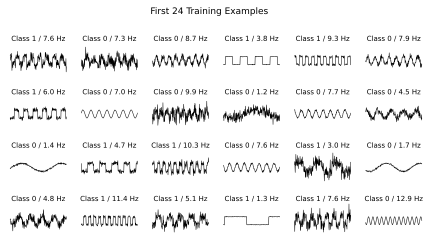

In [2]:
# Data Generation
def generate_waveform(length_signal=256, num_samples=1000):
    """
    Generate a dataset of noisy sine or square waveforms 
    with random frequency, phase, and noise.

    Each signal:
      - Prototype: sine (0) or square (1)
      - Frequency: sampled from [1, 13] Hz
      - Phase: sampled from [0, 1] (cycles)
      - Noise: Gaussian with std sampled from [0, 1]

    Returns:
        t (np.ndarray): Time axis, shape (length_signal,)
        X (np.ndarray): Noisy signals, shape (num_samples, length_signal)
        Y (np.ndarray): Metadata [prototype, frequency, phase, noise_std], 
                        shape (num_samples, 4)
    """
    t = np.linspace(0, 1, length_signal)
    X, Y = [], []

    for _ in range(num_samples):
        freq = np.random.uniform(1, 13)
        phase = np.random.uniform(0, 1)
        noise_std = np.random.uniform(0, 1)
        prototype = np.random.randint(0, 2)

        signal = np.sin(2 * np.pi * (freq * t - phase))
        if prototype == 1:
            signal = np.sign(signal)  # convert to square wave

        noisy = signal + np.random.normal(0.0, noise_std, size=length_signal)
        X.append(noisy)
        Y.append([prototype, freq, phase, noise_std])

    return t, np.array(X), np.array(Y)

# Custom PyTorch Dataset
class WaveformDataset(Dataset):
    def __init__(self, X, Y):
        super().__init__()
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Generate and prepare data
np.random.seed(0)
t, X, Y = generate_waveform()
visualize_pairs_24(t, X, Y)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)   # (N, 1, T)
Y_tensor = torch.tensor(Y[:, 0], dtype=torch.float32)          # (N,)

# Wrap in Dataset and DataLoader
dataset = WaveformDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

<a id='binaryclassificationpytorch'></a>  
## Binary Classification Using PyTorch

After preparing the dataset, we now demonstrate how PyTorch can be used to train and evaluate a model for binary classification. The model produces a single logit, which is transformed into a probability using the sigmoid function. Training is guided by the binary cross-entropy loss (`nn.BCEWithLogitsLoss()`), which compares the predicted probability to the true binary label. During evaluation, a threshold (commonly 0.5) is applied to the predicted probability to assign a class label. Accuracy is then computed by comparing these predictions to the reference annotations (sometimes also referred to as the ground truth). The main components involved in this training pipeline are:

* `nn.Conv1d`: Applies learnable filters to extract temporal features from a 1D input of `T` samples, with batch size `B` and number of output channels `C` (equal to the number of kernels).
* `nn.AdaptiveAvgPool1d`: Reduces the time dimension to a single value per channel by averaging over the entire temporal extent. This ensures a fixed output shape, regardless of input length, and makes it compatible with the following linear layer.
* `nn.Flatten`: Converts the pooled 3D tensor `(B, C, 1)` into a 2D tensor `(B, C)` before feeding it to the fully connected layer.
* `nn.Linear`: Maps the flattened features to a single output value (the logit).
* `nn.BCEWithLogitsLoss`: Combines a sigmoid activation with binary cross-entropy loss in a numerically stable way.
* `torch.sigmoid`: Converts the raw logit into a probability score in the range `(0, 1)`.
* Thresholding: Converts probabilities into binary class decisions by assigning `class 1` to values above `0.5` and `class 0` otherwise.
* `optim.Adam`: Optimizer that updates model parameters; the learning rate (`0.05`) controls the step size during training.


In [3]:
# Define a small CNN for binary classification
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv1d(1, 4, kernel_size=21, stride=5)  
        self.relu = nn.ReLU()                                  
        self.pool = nn.AdaptiveAvgPool1d(1)                    
        self.flatten = nn.Flatten()                            
        self.fc = nn.Linear(4, 1)                              

    def forward(self, x):
        x = self.conv(x)       # (B, 4, (T - 21)//5 + 1)
        x = self.relu(x)       # (B, 4, (T - 21)//5 + 1)
        x = self.pool(x)       # (B, 4, 1)
        x = self.flatten(x)    # (B, 4)
        x = self.fc(x)         # (B, 1)
        return x    

# Instantiate model, loss, and optimizer
torch.manual_seed(0)
model = SmallCNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# Display model summary for input with shape (B, C, T)
print(summary(model, input_size=(32, 1, 256), col_width=20))

# Training loop
n_epochs = 10
for epoch in range(n_epochs):
    total_loss = 0
    correct = 0
    total = 0
    for x_batch, y_batch in dataloader:
        logits = model(x_batch).view(-1)   # (B,1) -> (B,) to match y_batch   
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1:2d}/{n_epochs} | "
          f"Loss: {total_loss:7.4f} | Accuracy: {acc:.2f}%")

Layer (type:depth-idx)                   Output Shape         Param #
SmallCNN                                 [32, 1]              --
├─Conv1d: 1-1                            [32, 4, 48]          88
├─ReLU: 1-2                              [32, 4, 48]          --
├─AdaptiveAvgPool1d: 1-3                 [32, 4, 1]           --
├─Flatten: 1-4                           [32, 4]              --
├─Linear: 1-5                            [32, 1]              5
Total params: 93
Trainable params: 93
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.14
Input size (MB): 0.03
Forward/backward pass size (MB): 0.05
Params size (MB): 0.00
Estimated Total Size (MB): 0.08


Epoch  1/10 | Loss: 21.7922 | Accuracy: 53.80%
Epoch  2/10 | Loss: 17.4479 | Accuracy: 84.80%
Epoch  3/10 | Loss: 13.5566 | Accuracy: 84.60%
Epoch  4/10 | Loss:  8.7058 | Accuracy: 97.20%


Epoch  5/10 | Loss:  6.7747 | Accuracy: 96.90%
Epoch  6/10 | Loss:  4.5660 | Accuracy: 99.20%


Epoch  7/10 | Loss:  3.4174 | Accuracy: 99.20%
Epoch  8/10 | Loss:  2.2986 | Accuracy: 99.60%
Epoch  9/10 | Loss:  1.7392 | Accuracy: 99.90%


Epoch 10/10 | Loss:  1.5769 | Accuracy: 99.70%


The training results show rapid convergence, with accuracy surpassing 99% after just a few epochs. This suggests that distinguishing between noisy sine and square waves is a relatively easy task, even for a small convolutional network. However, such high performance can also indicate **overfitting**, so it is essential to test the model on new data to verify its generalization ability.

The code below generates a fresh test set, runs it through the trained model, and computes accuracy. Gradient tracking is disabled for efficiency, and predictions are derived by applying a sigmoid function followed by thresholding at 0.5. While the model performs well on this test set, its success is tied to the specific data generation process. Generalizing to signals with different noise levels or frequencies would require further validation.

In [4]:
np.random.seed(10)  # Set seed for reproducibility
t, X_test, Y_test = generate_waveform()

# Convert test data to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)  # (N, 1, T)
Y_test_tensor = torch.tensor(Y_test[:, 0], dtype=torch.float32)         # (N,)

# Disable gradient computation for evaluation
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor).view(-1)         # (N,)
    probs = torch.sigmoid(logits)                  # (N,)
    preds = (probs > 0.5).float()                  # Binary predictions: 0 or 1
    correct = (preds == Y_test_tensor).sum().item()
    accuracy = correct / len(Y_test_tensor)

print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 99.30%


<a id='nnsequential'></a>  
## Defining Compact Models with Sequential Layers

In PyTorch, neural networks are usually defined by creating a custom class that inherits from `nn.Module`, which allows precise control over the model's structure and data flow. While this is essential for complex architectures, it can be unnecessarily detailed for simpler cases. For basic feedforward models where layers are applied in sequence, PyTorch provides the `nn.Sequential` container. This approach simplifies the code by stacking layers directly without the need to define a `forward()` method. It is particularly well-suited for teaching, learning, and rapid prototyping.

The model below reimplements the earlier `SmallCNN` using `nn.Sequential`. It carries out the same sequence of operations, including convolution, activation, global pooling, flattening, and final classification, but presents them in a more compact and readable form. Compared to the original version, the `nn.Sequential` approach offers:

* **Same functionality**: Computes the same result as the original `SmallCNN` class.
* **Cleaner syntax**: Reduces repetitive code and improves clarity.
* **Easy modification**: Layers can be accessed and changed via indexing (e.g., `model[0] = nn.Conv1d(...)`).
* **Best for simple pipelines**: Works well when layers are applied in sequence; less suitable for models with branches, conditionals, or multiple inputs/outputs.

To use this version in your pipeline, simply replace  `model = SmallCNN()` with `model = SmallCNN_Sequential()`.

In [5]:
# Define a small CNN using nn.Sequential
class SmallCNN_Sequential(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=4, kernel_size=21, stride=5),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),              # Result: (B, 4)
            nn.Linear(4, 1)            # Output logit: (B, 1)
        )

    def forward(self, x):
        return self.model(x)  

# Instantiate model
torch.manual_seed(0)
model = SmallCNN_Sequential()

print("Layer-wise structure as stored in model.model:")
for i, layer in enumerate(model.model):
    print(f"model.model[{i}]: {layer}")

# Display model summary for input with shape (B, C, T)
summary(model, input_size=(32, 1, 256), col_width=20)

Layer-wise structure as stored in model.model:
model.model[0]: Conv1d(1, 4, kernel_size=(21,), stride=(5,))
model.model[1]: ReLU()
model.model[2]: AdaptiveAvgPool1d(output_size=1)
model.model[3]: Flatten(start_dim=1, end_dim=-1)
model.model[4]: Linear(in_features=4, out_features=1, bias=True)


Layer (type:depth-idx)                   Output Shape         Param #
SmallCNN_Sequential                      [32, 1]              --
├─Sequential: 1-1                        [32, 1]              --
│    └─Conv1d: 2-1                       [32, 4, 48]          88
│    └─ReLU: 2-2                         [32, 4, 48]          --
│    └─AdaptiveAvgPool1d: 2-3            [32, 4, 1]           --
│    └─Flatten: 2-4                      [32, 4]              --
│    └─Linear: 2-5                       [32, 1]              5
Total params: 93
Trainable params: 93
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.14
Input size (MB): 0.03
Forward/backward pass size (MB): 0.05
Params size (MB): 0.00
Estimated Total Size (MB): 0.08

<a id='background_multiclass_classification'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Multiclass Classification</h2>

<p style="color:#1B5E20;">
Extending the binary classification setup, <strong>multiclass classification</strong> refers to assigning each input to one of several possible categories. Let $K \in \mathbb{N}$ denote the number of classes, labeled as $k \in \{0, 1, \ldots, K - 1\}$. Instead of producing a single logit, the model outputs a vector of real-valued logits:
$$
\mathbf{z} = (z_0, z_1, \ldots, z_{K-1})^\top \in \mathbb{R}^K,
$$
where each $z_k$ reflects the model's unnormalized score for class $k$. To transform these scores into a valid probability distribution, the <strong>softmax function</strong> $\varphi: \mathbb{R}^K \to \mathbb{R}^K$ is commonly used:
$$
\varphi(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=0}^{K-1} e^{z_j}}, \quad \text{for } k \in \{0, 1, \ldots, K - 1\}.
$$
This ensures that the output vector $\mathbf{p} = \varphi(\mathbf{z})$ lies in the probability simplex: all components $p_k$ are positive and sum to 1. Therefore, these values can be interpreted as class probabilities. For example, consider a 3-class problem with logits $\mathbf{z} = (2.0,\ 1.0,\ 0.1)^\top$. Applying softmax yields:
$$
\varphi(\mathbf{z}) \approx (0.66,\ 0.24,\ 0.10)^\top,
$$
meaning the model assigns 66% probability to class 0, 24% to class 1, and 10% to class 2. These values correspond to the components $p_0$, $p_1$, and $p_2$ of $\mathbf{p} = \varphi(\mathbf{z})$.
</p>

<p style="color:#1B5E20;">
To train the model, the <strong>cross-entropy loss</strong> is used, which generalizes the binary case:
$$
\mathcal{L}(\mathbf{p}, y) = -\log(p_y),
$$
where $y \in \{0, 1, \ldots, K - 1\}$ is the true class label and $p_y$ is the predicted probability for class $y$, computed from $\mathbf{p} = \varphi(\mathbf{z})$. The loss is small when $p_y$ is close to 1 and large when $p_y$ is close to 0. This encourages the model to place high confidence on the correct class.
</p>

<p style="color:#1B5E20;">
The combination of softmax and cross-entropy is widely adopted in multiclass settings because it is:
</p>

<ul style="color:#1B5E20;">
  <li><strong>Probabilistically grounded:</strong> The softmax output provides interpretable class probabilities.</li>
  <li><strong>Smooth and differentiable:</strong> Ideal for gradient-based optimization due to its well-behaved loss landscape.</li>
  <li><strong>Numerically stable:</strong> Frameworks like PyTorch implement <code>nn.CrossEntropyLoss</code> with built-in stability, avoiding overflow/underflow issues.</li>
  <li><strong>Computationally efficient:</strong> The <code>log</code> and <code>exp</code> operations cancel each other out during differentiation, enabling efficient backpropagation.</li>
</ul>

<p style="color:#1B5E20;">
Together, softmax and cross-entropy form a principled and efficient foundation for training neural networks in multiclass classification tasks.
</p>
</div>


<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong>
The term <strong>softmax</strong> can be misleading. Despite its name, the softmax function $\varphi: \mathbb{R}^K \to \mathbb{R}^K$ does not approximate the maximum value $\max_k z_k$ of a vector $\mathbf{z} = (z_0, z_1, \ldots, z_{K-1})^\top$. Instead, it defines a probability distribution that smoothly approximates the <strong>argmax</strong>. Specifically, if one $z_k$ is much larger than all others, then $\varphi(\mathbf{z})$ closely resembles a one-hot encoding at the index $k$ of the maximum. In this sense, the name <strong>softargmax</strong> would be more accurate for $\varphi$. In contrast, the <strong>log-sum-exp</strong> function $\psi: \mathbb{R}^K \to \mathbb{R}$ defined by 
$$
\psi(\mathbf{z}) = \log \left( \sum_{k=0}^{K-1} e^{z_k} \right)
$$
is a smooth approximation of the maximum value itself, i.e., $\psi(\mathbf{z}) \approx \max_k z_k$. Importantly, the gradient of the soft maximum is the softmax:
$$
\nabla_{\mathbf{z}} \psi(\mathbf{z}) = \varphi(\mathbf{z}).
$$
Geometrically, the gradient points in the direction where the soft maximum increases fastest. Each component of $\varphi(\mathbf{z})$ shows how strongly the corresponding logit $z_k$ contributes to this increase.
</p>
</div>

<a id='multiclassfrequencyexample'></a>  
## Example: Classifying Waveforms by Frequency

To extend the binary classification task, we now consider a **multiclass classification** setting that builds directly on the previous example involving sine and square waveforms. In the binary case, we trained a model to distinguish between two waveform types: sine (`class 0`) and square (`class 1`). In the current scenario, we change the objective: instead of classifying based on waveform shape, we now classify each signal according to its **frequency**. 

More precisely, the continuous frequency variable, originally sampled uniformly between 1 and 13 Hz, is converted into a **categorical label**: instead of keeping the exact frequency value, we only record which class it belongs to. To this end, we divide the frequency axis into six predefined **ranges** (also called **bands**) and assign each value to one of these ranges, with each range representing a separate class:

- `class 0`: frequency < 2 Hz  
- `class 1`: 2 &le; frequency < 4 Hz  
- `class 2`: 4 &le; frequency < 6 Hz  
- `class 3`: 6 &le; frequency < 8 Hz  
- `class 4`: 8 &le; frequency < 10 Hz  
- `class 5`: frequency &ge; 10 Hz

This binning strategy reduces the number of classes to $K = 6$ and enables the model to focus on identifying coarse **frequency bands** rather than precise frequency values. Such a setup improves interpretability and is motivated by real-world applications such as pitch estimation for music recordings.

<a id='background_pitch_estimation'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Pitch and Fundamental Frequency (F0)</h2>

<p style="color:#1B5E20;">
In music, the term <strong>pitch</strong> refers to a perceptual attribute that allows us to order sounds from <strong>low</strong> to <strong>high</strong> along a frequency-related scale. When we speak about a note such as A4 or C5, we usually have in mind a pitched sound that is (approximately) periodic. Physically, such a sound can be characterized by its <strong>fundamental frequency</strong> (often denoted by <strong>F0</strong>), measured in Hertz. The fundamental frequency specifies how many periods of the waveform occur per second and serves as the primary physical correlate of the perceived pitch. For example, the note A4 has a fundamental frequency of 440 Hertz, which is the standard pitch typically used for tuning instruments in Western music, often realized by a tuning fork.
</p>

<p style="color:#1B5E20;">
Real musical sounds are typically not pure sinusoids, but consist of a fundamental frequency together with higher partials and additional noise components. As long as a reasonably stable periodic structure is present, we can associate a dominant fundamental frequency (F0) to the sound, and this F0 is closely linked to the pitch we perceive. In Music Information Retrieval (MIR), estimating F0 is a central task that supports applications such as melody extraction, automatic transcription, tuning and intonation analysis, and the characterization of singers and instruments.
</p>

<p style="color:#1B5E20;">
From a modeling point of view, there are two common perspectives. In a <strong>regression-based</strong> approach, F0 is treated as a continuous quantity, and the goal is to predict precise frequency values (for example in Hertz or in cents). In a <strong>classification-based</strong> approach, the continuous frequency axis is grouped into a finite set of frequency bins (classes), and the task is to decide which class is active. This matches how pitch is often treated in music theory and MIR: listeners usually think in terms of pitch categories (such as scale steps or semitones) rather than exact frequency values, and equal pitch steps correspond to frequency intervals that grow wider in Hertz at higher pitches. Using frequency bins therefore provides a natural link between continuous frequency and categorical pitch labels. In our current setup, the continuous frequency variable (here ranging from 1 to 13&nbsp;Hz) is converted into a categorical label by assigning each value to one of six predefined frequency ranges. In real F0 estimation applications, such a coarse quantization reduces the number of classes, increases robustness to small frequency fluctuations, and helps tie the model outputs to musically meaningful pitch regions and standard pitch-bin representations in MIR.
</p>
</div>

We continue using the same dataset `X` and metadata `Y` as in the binary case. The signals `X` are converted to tensors of shape `(N, 1, T)` to ensure compatibility with 1D convolutional layers. The frequency values from `Y[:, 1]` are quantized into one of the six class labels according to the frequency bands above. These class labels are cast to `torch.long` to be compatible with `nn.CrossEntropyLoss`, which is used during training. Only the **frequency band class** serves as the target label, turning the problem into a 6-class classification task.

In [6]:
# Define custom bin ranges (in Hz) for frequency-based classification
bins = [0, 2, 4, 6, 8, 10, np.inf]  # 6 bins -> class indices 0 to 5
class_names = [
    "[0, 2)",
    "[2, 4)",
    "[4, 6)",
    "[6, 8)",
    "[8, 10)",
    "[10, \u221e)"
]

# Assign each frequency to a class label (0–5)
Y_freq = Y[:, 1]                         # Extract frequency values
Y_class = np.digitize(Y_freq, bins) - 1  # Map each value to a bin index 0–5

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)   # (N, 1, T)   
# nn.CrossEntropyLoss expects class indices with dtype torch.long (int64)
Y_tensor = torch.tensor(Y_class, dtype=torch.long)             # (N,)

# Wrap in Dataset and DataLoader
dataset = WaveformDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Display a few examples: signal -> frequency -> range -> class label
print("Examples of frequency-to-class mapping:")
for i in range(5):
    freq = Y_freq[i]
    cls = Y_class[i]
    label = class_names[cls]
    print(f"Signal {i:1d}: Frequency = {freq:.2f} Hz -> Class {cls} ({label} Hz)")

Examples of frequency-to-class mapping:
Signal 0: Frequency = 7.59 Hz -> Class 3 ([6, 8) Hz)
Signal 1: Frequency = 7.30 Hz -> Class 3 ([6, 8) Hz)
Signal 2: Frequency = 8.67 Hz -> Class 4 ([8, 10) Hz)
Signal 3: Frequency = 3.76 Hz -> Class 1 ([2, 4) Hz)
Signal 4: Frequency = 9.33 Hz -> Class 4 ([8, 10) Hz)


While we have reformulated our task as a 6-class frequency classification problem based on predefined frequency bands, it is important to examine how the data is distributed across these classes. In many real-world scenarios, **class imbalance** occurs when some categories are much more common than others. This can cause models to favor frequent classes while performing poorly on rare ones.

In our setup, the frequency values were sampled uniformly between 1 and 13 Hz and then grouped into broad frequency ranges. This binning process may lead to an uneven class distribution. To check this, we now plot a histogram of the resulting class labels. Inspecting class balance before training is a valuable step, as it helps identify potential problems early and guides decisions such as adjusting the loss function or augmenting data for underrepresented classes.

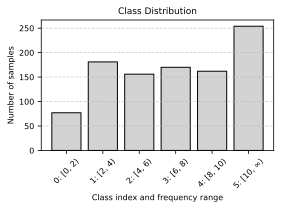

In [7]:
# Compute histogram of class labels (0 to 5)
counts = np.bincount(Y_class, minlength=len(class_names))
classes = np.arange(len(class_names))

# Plot the class distribution with improved formatting
plt.figure(figsize=(4, 3))
plt.bar(classes, counts, color="lightgray", edgecolor="black")

# Format x-axis with class index and corresponding range
x_labels = [f"{i}: {name}" for i, name in enumerate(class_names)]
plt.xticks(classes, x_labels, fontsize=8, rotation=45)
plt.yticks(fontsize=8)  # Set y-axis tick font size

plt.xlabel("Class index and frequency range", fontsize=8)
plt.ylabel("Number of samples", fontsize=8)
plt.title("Class Distribution", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

<a id='multiclassclassificationpytorch'></a>  
## Multiclass Classification Using PyTorch

The multiclass classification pipeline builds directly on the binary case and uses the same core components. We apply 1D convolutional layers to extract temporal features from waveforms, reduce the time dimension using striding and pooling, and map the resulting features to class scores through a fully connected layer. Since multiclass classification involves selecting from several possible output categories rather than just two, we use a slightly deeper model with two convolutional layers to better handle the increased task complexity. In addition to this architectural change, there are two key conceptual differences between the multiclass and binary setups:

- **Output and activation**: In binary classification, the model outputs a single logit passed through a sigmoid to produce a probability for class `1`. In multiclass classification, it outputs a vector of logits&mdash;one per class. These are passed directly to `nn.CrossEntropyLoss`, which internally applies softmax to obtain a probability distribution over all classes.

- **Loss and prediction**: `nn.BCEWithLogitsLoss` is used in the binary case to compare the predicted probability to a label `0` or `1`. In the multiclass case, `nn.CrossEntropyLoss` expects an integer class label (`0` to `K-1`) and computes the loss based on the softmax probabilities. At test time, the predicted class is taken as the index of the highest logit using `torch.argmax`, instead of thresholding.

The following example demonstrates how to implement and train such a model using PyTorch.

In [8]:
# Define an enhanced CNN for multiclass classification (6 frequency band classes)
class FrequencyClassifier(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=21, stride=5),   # (B, 1, 256) -> (B, 8, 48)
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=5, stride=2),   # (B, 8, 48) -> (B, 16, 22)
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),                     # (B, 16, 22) -> (B, 16, 1)
            nn.Flatten(),                                # (B, 16, 1) -> (B, 16)
            nn.Linear(16, num_classes)                   # Output logits: (B, 6)
        )

    def forward(self, x):
        return self.model(x)

# Set random seed for reproducibility
torch.manual_seed(0)

# Instantiate the model for 6-class classification
model = FrequencyClassifier(num_classes=6)

# Display model summary for input with shape (B, C, T)
summary(model, input_size=(32, 1, 256), col_width=20)

Layer (type:depth-idx)                   Output Shape         Param #
FrequencyClassifier                      [32, 6]              --
├─Sequential: 1-1                        [32, 6]              --
│    └─Conv1d: 2-1                       [32, 8, 48]          176
│    └─ReLU: 2-2                         [32, 8, 48]          --
│    └─Conv1d: 2-3                       [32, 16, 22]         656
│    └─ReLU: 2-4                         [32, 16, 22]         --
│    └─AdaptiveAvgPool1d: 2-5            [32, 16, 1]          --
│    └─Flatten: 2-6                      [32, 16]             --
│    └─Linear: 2-7                       [32, 6]              102
Total params: 934
Trainable params: 934
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.74
Input size (MB): 0.03
Forward/backward pass size (MB): 0.19
Params size (MB): 0.00
Estimated Total Size (MB): 0.23

In [9]:
# Set random seed for reproducibility
torch.manual_seed(0)

# Loss function for multiclass classification: CrossEntropyLoss
# - Takes raw logits (not probabilities)
# - Expects integer class labels in [0, ..., K-1] with dtype torch.long (int64)
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
model.train()
n_epochs = 10
for epoch in range(n_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in dataloader:
        logits = model(x_batch)             # Predicted logits, shape (B, 6)
        loss = criterion(logits, y_batch)   # Cross-entropy loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Prediction: choose the class with highest logit (no thresholding)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1:2d}/{n_epochs} | Loss: {total_loss:7.4f} | "
          f"Accuracy: {acc:.2f}%")

Epoch  1/10 | Loss: 40.3693 | Accuracy: 49.90%
Epoch  2/10 | Loss: 18.3456 | Accuracy: 76.30%


Epoch  3/10 | Loss: 11.0618 | Accuracy: 87.30%
Epoch  4/10 | Loss:  9.2453 | Accuracy: 87.70%


Epoch  5/10 | Loss:  7.5886 | Accuracy: 90.00%
Epoch  6/10 | Loss:  8.3629 | Accuracy: 88.70%


Epoch  7/10 | Loss:  5.8032 | Accuracy: 92.50%
Epoch  8/10 | Loss:  5.5641 | Accuracy: 92.30%
Epoch  9/10 | Loss:  5.2213 | Accuracy: 94.20%


Epoch 10/10 | Loss:  6.6815 | Accuracy: 92.70%


The training curves show a clear learning progress, with accuracy rising from about 50% to well above 90% within fewer than 10 epochs. This indicates that the model effectively learns to distinguish between coarse frequency ranges, even though the task is clearly more challenging than the previous binary classification setting (distinguishing sine from square waves). Note that training for more epochs might further improve performance, but this is not our main focus here; instead, we proceed with this reasonable result to gain a more detailed understanding of the model’s behavior and to analyze typical error cases.

<a id='evaluation'></a>  
## Model Evaluation and Understanding

To evaluate generalization, we now test the model on a newly generated, independent test set. As in the binary case, we compute overall accuracy. In addition, we visualize a **confusion matrix**, which is a table that compares predicted class labels to true labels. Each row of the matrix corresponds to an actual class, while each column represents a predicted class. Ideally, all predictions fall along the diagonal, indicating correct classifications. Off-diagonal entries show where the model confuses one class for another, offering a detailed view of its performance across categories.

Test Accuracy: 91.90%


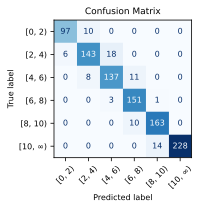

In [10]:
# Generate a new, independent test set
np.random.seed(10)
t_test, X_test, Y_test = generate_waveform()

# Extract true frequencies and map them to class labels
Y_test_freq = Y_test[:, 1]
Y_test_class = np.digitize(Y_test_freq, bins) - 1

# Convert to tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
Y_test_tensor = torch.tensor(Y_test_class, dtype=torch.long)

# Evaluate model
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    preds = torch.argmax(logits, dim=1)
    accuracy = (preds == Y_test_tensor).float().mean().item()

print(f"Test Accuracy: {accuracy:.2%}")

compute_and_plot_confusion_matrix(Y_test_tensor.numpy(), preds.numpy(), class_names);

The confusion matrix shows that misclassifications occur exclusively between **neighboring frequency classes**, suggesting that errors tend to arise near **class boundaries**. To explore this, the plot below shows the **signed distance to the nearest class boundary** versus the true frequency. Gray points indicate correct classifications, red points indicate errors. Distances near zero reflect proximity to a boundary, with the sign showing on which side of the threshold the frequency lies. This helps reveal whether errors cluster near decision regions and which frequency ranges are most affected.  

**Note:** Signed distances may exceed the value one only in the highest frequency class, as the waveform generator produces frequencies between **1 Hz and 13 Hz**, while the final bin is open-ended (<code>[10, &infin;)</code>).


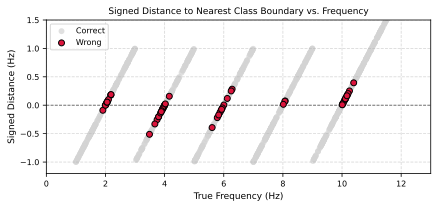

In [11]:
plot_signed_distance_vs_frequency(model, X_tensor, Y_tensor, Y, bins)

Finally, we analyze the model's behavior outside the training frequency range.  All previous evaluations assumed test data with frequencies between 1 Hz and 13 Hz. Since the model has never encountered frequencies lower or higher during training,   conclusions beyond this range must be drawn with caution. 

Nonetheless, it is insightful to explore how the model responds to such a distributional shift, commonly known as **out-of-distribution generalization** or **domain shift**.  While handling such situations often requires retraining or fine-tuning, we test the model's extrapolation ability by feeding it waveforms with frequencies well outside the training range and observing its predicted class labels and confidence scores.

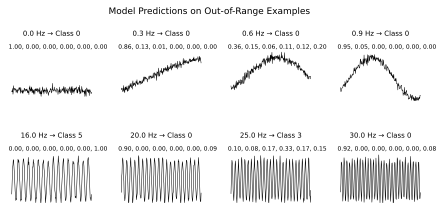

In [12]:
# Set random seed for reproducibility
np.random.seed(40)

# Waveform generation for single sample
def generate_single_waveform(freq, phase=0.0, noise_std=0.0, prototype=0, t=None):
    signal = np.sin(2 * np.pi * (freq * t - phase))
    if prototype == 1:
        signal = np.sign(signal)
    noisy = signal + np.random.normal(0.0, noise_std, size=len(t))
    return noisy, [prototype, freq, phase, noise_std]

# Generate 8 out-of-distribution signals
test_freqs = [0.0, 0.3, 0.6, 0.9, 16, 20, 25, 30]
t = np.linspace(0, 1, 256)

X_out, Y_meta = [], []
for freq in test_freqs:
    x, meta = generate_single_waveform(freq, phase=0.1, noise_std=0.1, 
                                       prototype=0, t=t)
    X_out.append(x)
    Y_meta.append(meta)

X_out = np.array(X_out)
Y_meta = np.array(Y_meta)

# Run model prediction
X_out_tensor = torch.tensor(X_out, dtype=torch.float32).unsqueeze(1)
model.eval()
with torch.no_grad():
    logits = model(X_out_tensor)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

# Visualize results
visualize_out_of_range_predictions(
    t=t,
    X=X_out,
    freqs=test_freqs,
    preds=preds.numpy(),
    probs=probs.numpy(),
    title="Model Predictions on Out-of-Range Examples"
)

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Summarizing Note:</strong>  When switching between binary and multiclass classification in PyTorch, it is essential to adjust your model architecture, activation functions, and loss functions accordingly.  A common pitfall is using the wrong combination of output shapes, label formats, or loss functions. The table below summarizes the key differences to help you avoid such mistakes:
</p>

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

  <table style="width:90%; border-collapse: collapse; margin-top: 10px; table-layout: fixed;">
    <colgroup>
        <col style="width:20%;">
        <col style="width:35%;">
        <col style="width:35%;">
    </colgroup>
    <thead>
        <tr style="background-color: #e3e3e3; text-align: left;">
            <th style="border: 1px solid #ccc; padding: 6px;">Aspect</th>
            <th style="border: 1px solid #ccc; padding: 6px;">Binary Classification</th>
            <th style="border: 1px solid #ccc; padding: 6px;">Multiclass Classification</th>
        </tr>
    </thead>
    <tbody>
        <tr style="background-color: white; transition: none;">
            <td style="border: 1px solid #ccc; padding: 6px;">Output</td>
            <td style="border: 1px solid #ccc; padding: 6px;">
                Single scalar logit, converted to probability <code>p</code> of <code>class 1</code> via sigmoid; probability of <code>class 0</code> is then <code>1 − p</code>.
            </td>
            <td style="border: 1px solid #ccc; padding: 6px;">
                Vector of logits (one per class), converted to class probabilities via softmax; ensures that all probabilities sum to one.
            </td>
        </tr>
        <tr style="background-color: white; transition: none;">
            <td style="border: 1px solid #ccc; padding: 6px;">Activation</td>
            <td style="border: 1px solid #ccc; padding: 6px;">
                Sigmoid (applied internally by <code>BCEWithLogitsLoss</code>)</span>
            </td>
            <td style="border: 1px solid #ccc; padding: 6px;">
                Softmax (applied internally by <code>CrossEntropyLoss</code>)</span>
            </td>
        </tr>
        <tr style="background-color: white; transition: none;">
            <td style="border: 1px solid #ccc; padding: 6px;">Loss Function</td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>nn.BCEWithLogitsLoss</code></td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>nn.CrossEntropyLoss</code></td>
        </tr>
        <tr style="background-color: white; transition: none;">
            <td style="border: 1px solid #ccc; padding: 6px;">Target Data Type</td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>torch.float</code> to encode value 0.0 or 1.0</td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>torch.long</code> (<code>int64</code>) to encode integer class index</td>
        </tr>
        <tr style="background-color: white; transition: none;">
            <td style="border: 1px solid #ccc; padding: 6px;">Prediction Rule</td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>prob &gt; 0.5 &rarr; 1 else 0</code></td>
            <td style="border: 1px solid #ccc; padding: 6px;"><code>argmax(logits)</code></td>
        </tr>
    </tbody>
  </table>
</div>


<a id='exercise_binary_cross_entropy'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Understanding Binary Cross-Entropy Loss</strong><br>

<p style="color:#006064;">
In binary classification, a model outputs a probability $p \in (0,1)$ for the positive class, and the true label is $y \in \{0,1\}$. The <strong>binary cross-entropy (BCE) loss</strong> is a standard loss function that quantifies how well the predicted probability matches the true label:
$$
\mathcal{L}(p, y) = - \left[ y \log(p) + (1 - y) \log(1 - p) \right].
$$
</p>

<p style="color:#006064;">
Your goal is to explore how this loss function behaves and understand why it is well-suited for binary classification tasks.
</p>

<ul style="color:#006064;">
  <li>Implement a Python function <code>binary_cross_entropy(p, y)</code> for $\mathcal{L}(p, y)$. Since $\log(0)$ is undefined, clip values of <code>p</code> to a safe range before applying the logarithm.</li>

  <li>Plot the BCE loss as a function of $p \in (0, 1)$ for two cases:
    <ul style="color:#006064;">
      <li>When <code>y = 1</code>, the loss simplifies to $-\log(p)$</li>
      <li>When <code>y = 0</code>, the loss simplifies to $-\log(1 - p)$</li>
    </ul>
  </li>      

  <li>Interpret and discuss the results:
    <ul style="color:#006064;">
      <li>Why is the loss high when $p$ is close to 0 but $y = 1$?</li>
      <li>What happens when the prediction is uncertain (e.g., $p \approx 0.5$)?</li>
      <li>When does the loss approach zero?</li>
      <li>Why does the loss penalize confident but wrong predictions more than uncertain ones?</li>
    </ul>
  </li>
</ul>
</div>

In [13]:
# Your Solution

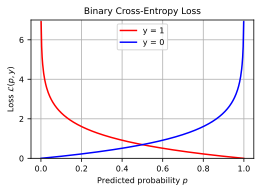

In [14]:
# Run and show output of the reference solution
exercise_binary_cross_entropy()

<a id='background_logistic_loss'></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#1B5E20;">Background: Logistic Loss</h2>

<p style="color:#1B5E20;">
We now take a closer look at the mathematical formulation behind binary classification. Specifically, we examine why combining the binary cross-entropy (BCE) loss $\mathcal{L}(p, y)$ with the sigmoid function $\sigma(z)$, which maps logits $z$ to probabilities $p = \sigma(z)$, leads to an effective and stable training objective. When the binary cross-entropy loss is applied to the sigmoid output, we obtain a composite function known as the <strong>logistic loss</strong>, defined by
$$
\mathcal{J}(z, y) := \mathcal{L}(\sigma(z), y) = -\left[y \log(\sigma(z)) + (1 - y) \log(1 - \sigma(z))\right].
$$
Using algebraic identities, this expression can be simplified to a numerically stable and computationally efficient form:
$$
\mathcal{J}(z, y) = \log(1 + e^{-z}) + (1 - y) \, z.
$$
This reformulation avoids numerical instability that may arise when computing logarithms of values close to $0$ or $1$ in the original BCE loss. It also enables direct computation from the logit $z$ without needing to explicitly evaluate the sigmoid function. Moreover, the derivative of the logistic loss is remarkably simple:
$$
\frac{d}{dz} \mathcal{J}(z, y) = \sigma(z) - y.
$$
This reveals a key insight: the gradient is simply the prediction error. When the model is confident (i.e., $\sigma(z)$ is close to 1) and correct ($y = 1$), the gradient is near zero. In contrast, when the model is confident but wrong (for example, $\sigma(z)$ is close to 1 but $y = 0$), the gradient becomes large. This elegant combination of sigmoid and log-likelihood produces smooth gradients, enables stable optimization, and supports interpretable learning behavior. These qualities explain why the logistic loss is a central tool in binary classification, offering both theoretical clarity and practical robustness.
</p>

<p style="color:#1B5E20;">
<strong>Exercise:</strong> For readers interested in the mathematical derivation, we recommend deriving the reformulation of $\mathcal{J}(z, y)$ and its derivative. As a helpful hint, first prove the identity $1 - \sigma(z) = (1 + e^z)^{-1}$.
</p>
</div>

<a id='exercise_softmax_multiclass'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Exploring Softmax and Cross-Entropy in Multiclass Classification</strong><br>

<p style="color:#006064;">
This exercise helps you build intuition for how the <strong>softmax</strong> function transforms logits into probabilities and how the <strong>cross-entropy loss</strong> evaluates the quality of predictions based on the target (i.e., true class label). We consider the case of <code>K = 4</code> classes. Make sure to import <code>torch.nn.functional as F</code>.
</p>

<ul style="color:#006064;">
  <li>Define a list of examples, each containing a logit vector (e.g., <code>z = [1.0, 2.0, 3.0, 4.0]</code>) and a corresponding class index as target (e.g., <code>target = 3</code>).</li>
  <li>Use <code>F.softmax</code> to convert the logits <code>z</code> into a class probability vector <code>p</code>.</li>
  <li>Compute the cross-entropy loss for each example manually by taking the negative logarithm of the probability assigned to the true class using <code>torch.log</code>.</li>
  <li>Print all results row-wise: logits, softmax probabilities, target index, and loss value.</li>
  <li>Compute and report the average cross-entropy loss over all examples.</li>
  <li>Compare your manual result with the built-in function <code>F.cross_entropy(logits_tensor, targets_tensor)</code>. To do so, convert your example list into suitable tensors <code>logits_tensor</code> and <code>targets_tensor</code>.</li>
</ul>

<p style="color:#006064;">
Try changing the logits to see how softmax adjusts the predicted probabilities. Notice how cross-entropy loss is high for confident wrong predictions and lower for uncertain ones. This indicates how the model learns during training.
</p>
</div>

In [15]:
# Your Solution

In [16]:
# Run and show output of the reference solution
exercise_softmax_multiclass()

Example  Logit vector z         Probability vector p = softmax(z)   Target Loss    
---------------------------------------------------------------------------------
1        [0.0, 0.0, 0.0, 0.0]   [0.2500, 0.2500, 0.2500, 0.2500]    0      1.3863  
2        [1.0, 0.0, 0.0, 0.0]   [0.4754, 0.1749, 0.1749, 0.1749]    0      0.7437  
3        [1.0, 0.0, 0.0, 0.0]   [0.4754, 0.1749, 0.1749, 0.1749]    1      1.7437  
4        [2.0, 0.0, 0.0, 0.0]   [0.7112, 0.0963, 0.0963, 0.0963]    0      0.3408  
5        [2.0, 0.0, 0.0, 0.0]   [0.7112, 0.0963, 0.0963, 0.0963]    1      2.3408  
6        [1.0, 2.0, 3.0, 4.0]   [0.0321, 0.0871, 0.2369, 0.6439]    3      0.4402  
7        [6.0, 1.0, 2.0, 1.0]   [0.9692, 0.0065, 0.0178, 0.0065]    0      0.0313  
8        [6.0, 1.0, 2.0, 1.0]   [0.9692, 0.0065, 0.0178, 0.0065]    1      5.0313  
9        [6.0, 0.1, 2.0, 1.0]   [0.9730, 0.0027, 0.0178, 0.0066]    1      5.9274  
10       [6.0, -1.1, 2.0, 1.0]  [0.9748, 0.0008, 0.0179, 0.0066]    1      7.1

<a id='exercise_classification_FFT'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Frequency Classification from FFT Features</strong><br>

<p style="color:#006064;">
We revisit the waveform classification problem, which involves assigning each signal to one of six frequency bands:
<code>[0,2)</code>, <code>[2,4)</code>, <code>[4,6)</code>, <code>[6,8)</code>, <code>[8,10)</code>, and <code>[10, &infin;)</code>. However, instead of feeding the raw time-domain waveforms (length <code>256</code>) into the model, we transform each signal into the frequency domain using the Fast Fourier Transform (FFT). This yields a frequency-based representation that is often better suited for tasks involving frequency classification. Your goal is to explore whether this feature transformation improves classification by completing the following steps:
</p>

<ul style="color:#006064;">
  <li>Use the same waveform dataset as before, consisting of <code>1000</code> sine or square signals:<br>
      <code>np.random.seed(0)</code> and <code>t, X, Y = generate_waveform()</code>
  </li>
  <li>For each signal, compute the FFT using <code>np.fft.rfft(X)</code>. Use the absolute values to obtain the magnitude spectrum. Keep only the first <code>40</code> FFT coefficients and normalize each spectrum by its maximum value (per sample).</li>
  <li>Implement a simple neural network with a single <code>Linear</code> layer that maps the 40-dimensional FFT input to 6 output classes (frequency bands).</li>
  <li>Train the model using the cross-entropy loss and evaluate its accuracy on an independent test set:<br>
    <code>np.random.seed(10)</code> and <code>t_test, X_test, Y_test = generate_waveform()</code>
  </li>
  <li>Plot a confusion matrix to interpret the model's behavior across the frequency bands.</li>
</ul>

<p style="color:#006064;">
This exercise helps demonstrate how transforming inputs into a more meaningful feature space (here, the frequency domain) can make learning simpler and more effective. As an extension, try experimenting with alternative network architectures and input types. For example, compare classification performance using waveform signals, FFT features, or combinations of both.
</p>
</div>

In [17]:
# Your Solution

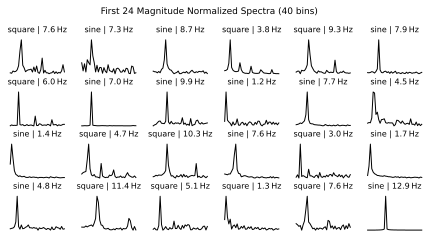


Model summary using torchinfo.summary:

Layer (type:depth-idx)                   Output Shape         Param #
FFTClassifier                            [32, 6]              --
├─Sequential: 1-1                        [32, 6]              --
│    └─Flatten: 2-1                      [32, 40]             --
│    └─Linear: 2-2                       [32, 6]              246
Total params: 246
Trainable params: 246
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

Training model...

Epoch  1/10 | Loss: 30.4280 | Accuracy: 74.60%
Epoch  2/10 | Loss: 10.8301 | Accuracy: 93.00%
Epoch  3/10 | Loss:  7.5087 | Accuracy: 94.50%
Epoch  4/10 | Loss:  6.1806 | Accuracy: 95.00%
Epoch  5/10 | Loss:  5.5045 | Accuracy: 94.70%


Epoch  6/10 | Loss:  4.9981 | Accuracy: 95.50%
Epoch  7/10 | Loss:  4.5114 | Accuracy: 95.30%
Epoch  8/10 | Loss:  4.2965 | Accuracy: 95.50%
Epoch  9/10 | Loss:  4.1384 | Accuracy: 96.10%


Epoch 10/10 | Loss:  3.9543 | Accuracy: 96.60%

Test Accuracy: 92.80%


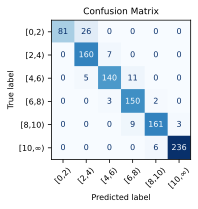

In [18]:
# Run and show output of the reference solution
exercise_classification_FFT()

<a id='exercise_pointcloud_classification'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 4: Classification of Intertwined 2D Point Clouds</strong><br>

<p style="color:#006064;">
In this exercise, you will explore a synthetic 2D classification task involving three intertwined point clouds that are not linearly separable. The goal is to build a neural network that can correctly separate the classes. You may use the following utility functions to support your implementation:
</p>
<ul style="color:#006064;">
  <li><code>generate_pointcloud()</code>: Generates a 3-class dataset consisting of two intertwined spirals and one Gaussian blob.</li>
  <li><code>plot_pointcloud(dataset)</code>: Visualizes the 2D input features colored by class.</li>
  <li><code>plot_decision_boundary(model, dataset)</code>: Displays the decision regions learned by the trained model.</li>
</ul>
<p style="color:#006064;">
Your task is to implement and train a neural network classifier that maps each 2D input point to one of the three classes. Complete the following steps:
</p>
<ul style="color:#006064;">
  <li>Generate the dataset using:<br><code>dataset = generate_pointcloud(n_points_per_class=300, noise=0.15, seed=0)</code></li>
  <li>Visualize the dataset with <code>plot_pointcloud(dataset)</code> to understand the class structure.</li>
  <li>Define a feedforward neural network consisting of several <code>Linear</code> layers with <code>ReLU</code> activations. Use 2D input and 3 output units (one per class).</li>
  <li>Train your model using the cross-entropy loss function and the Adam optimizer (e.g., with a learning rate of <code>lr=0.01</code>). Run the training for <code>100</code> epochs, and monitor both the training loss and accuracy throughout.</li>
  <li>Use <code>plot_decision_boundary(model, dataset)</code> to visualize how well the model separates the three classes.</li>
  <li>Experiment with alternative architectures by varying the network depth and the number of neurons per layer. Try both simpler and more complex models, and compare their performance.</li>
  <li>Generate a separate test dataset by changing the <code>noise</code> and <code>seed</code> parameters in <code>generate_pointcloud()</code>. Evaluate your trained model on this test set and discuss how model complexity and generalization behave under slight variations in the data.</li>
</ul>
<p style="color:#006064;">
This exercise highlights the challenges posed by non-linearly separable data and the importance of model capacity in learning complex decision boundaries.
</p>
</div>

In [19]:
# dataset = generate_pointcloud(n_points_per_class=300, noise=0.15, seed=0)
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
# plot_pointcloud(dataset) 

# # Your Solution

# plot_decision_boundary(model, dataset)

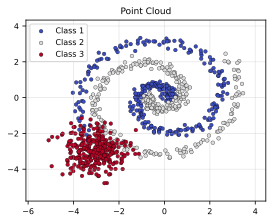


Model summary using torchinfo.summary:

Layer (type:depth-idx)                   Output Shape         Param #
SimpleMLP                                [64, 3]              --
├─Sequential: 1-1                        [64, 3]              --
│    └─Linear: 2-1                       [64, 32]             96
│    └─ReLU: 2-2                         [64, 32]             --
│    └─Linear: 2-3                       [64, 32]             1,056
│    └─ReLU: 2-4                         [64, 32]             --
│    └─Linear: 2-5                       [64, 16]             528
│    └─ReLU: 2-6                         [64, 16]             --
│    └─Linear: 2-7                       [64, 3]              51
Total params: 1,731
Trainable params: 1,731
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.01
Estimated Total Size (MB): 0.05
Epoch   1/100 | Loss: 11.4934 | Accuracy: 60.22%


Epoch  10/100 | Loss:  8.1481 | Accuracy: 66.33%


Epoch  20/100 | Loss:  6.3639 | Accuracy: 76.22%


Epoch  30/100 | Loss:  6.1351 | Accuracy: 80.56%


Epoch  40/100 | Loss:  3.5038 | Accuracy: 90.00%


...

Epoch  60/100 | Loss:  2.0567 | Accuracy: 94.33%


Epoch  70/100 | Loss:  1.4944 | Accuracy: 95.11%


Epoch  80/100 | Loss:  1.4962 | Accuracy: 95.11%


Epoch  90/100 | Loss:  3.7337 | Accuracy: 91.67%


Epoch 100/100 | Loss:  2.2177 | Accuracy: 94.22%

Final accuracy (entire training set; not averaged over batches): 95.33%


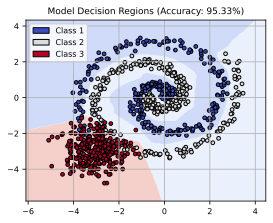

In [20]:
# Run and show output of the reference solution
model = exercise_pointcloud_classification()

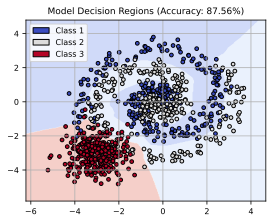

In [21]:
# Generate a *new* point cloud dataset with different noise and seed
# This acts as a test set to evaluate the generalization ability of the trained model
# dataset = generate_pointcloud(n_points_per_class=300, noise=0.15, seed=3)
dataset = generate_pointcloud(n_points_per_class=300, noise=0.30, seed=3)
# The decision boundary plot includes classification accuracy on this new set
plot_decision_boundary(model, dataset)

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>